## 0 · Install Dependencies


In [1]:
!pip install torch torchvision nibabel pandas scikit-learn tqdm matplotlib scipy seaborn -q


## 1 · Imports


In [2]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from tqdm.notebook import tqdm

import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 34
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU   : NVIDIA GeForce RTX 3090
VRAM  : 25.4 GB


## 2 · Configuration


In [3]:
CSV_PATH     = "OASIS3_metadata_final.csv"
IMAGE_DIR    = "."

TARGET_SHAPE = (96, 96, 96)   # (D, H, W)

# Optuna settings
N_TRIALS          = 30    # number of hyperparameter combinations to try
EPOCHS_PER_TRIAL  = 5    # quick epochs per trial to compare candidates
EPOCHS_FINAL      = 50    # full training with the best hyperparams

## 3 · Load Metadata & Create Labels


In [4]:
df = pd.read_csv(CSV_PATH)
print(f"Raw CSV rows: {len(df)}")

df["label"] = df["DEMENTED"].astype(int)
df = df[(df["DEMENTED"] + df["NORMCOG"]) == 1]
print(f"After consistency filter: {len(df)}")

display(df[["Subject_ID", "DEMENTED", "NORMCOG", "label"]].head())
print("\nLabel distribution:")
display(df["label"].value_counts().rename({0: "Normal", 1: "Demented"}))

Raw CSV rows: 1086
After consistency filter: 1086


,Subject_ID,DEMENTED,NORMCOG,label
0,OAS30001,0,1,0
1,OAS30002,0,1,0
2,OAS30003,0,1,0
3,OAS30004,0,1,0
4,OAS30005,0,1,0



Label distribution:


label
Normal      686
Demented    400
Name: count, dtype: int64

## 4 · Match Subjects → NIfTI Files


In [5]:
all_images = glob.glob(os.path.join(IMAGE_DIR, "**/*.nii.gz"), recursive=True)
print(f"NIfTI files found: {len(all_images)}")

subject_to_path = {}
for img_path in all_images:
    filename = os.path.basename(img_path)
    for subject_id in df["Subject_ID"].unique():
        if subject_id in filename:
            subject_to_path[subject_id] = img_path
            break

df["image_path"] = df["Subject_ID"].map(subject_to_path)
missing = df["image_path"].isna().sum()
print(f"Subjects without MRI: {missing}")
df = df.dropna(subset=["image_path"])
print(f"Final dataset size  : {len(df)}")

NIfTI files found: 1188
Subjects without MRI: 0
Final dataset size  : 1086


## 5 · Reproduce Exact Same Train / Val / Test Split

**Critical:** use the same seed, stratification and proportions as during training.


In [6]:
# Stratify by label + age bin + gender to ensure balanced distributions:
df["age_bin"] = (df["Age"] >= 75).astype(int)
df["strat"]   = (
    df["label"].astype(str) + "_" +
    df["age_bin"].astype(str) + "_" +
    df["Gender"].astype(str)   # 1 = male, 2 = female
)

print("Stratum distribution:\n", df["strat"].value_counts())

train_df, temp_df = train_test_split(
    df, test_size=0.4, stratify=df["strat"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["strat"], random_state=SEED
)

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n── {name} ──")
    print(split["label"].value_counts(normalize=True).rename({0: "Normal", 1: "Demented"}))
    print(f"Age mean : {split['Age'].mean():.1f}  std: {split['Age'].std():.1f}")
    print(f"Gender   : {split['Gender'].value_counts(normalize=True).rename({1: 'Male', 2: 'Female'}).to_dict()}")

Stratum distribution:
 strat
0_0_2    343
0_0_1    235
1_1_1    119
1_1_2    108
1_0_1     92
1_0_2     81
0_1_2     63
0_1_1     45
Name: count, dtype: int64

Train: 651  |  Val: 217  |  Test: 218
Total: 1086

── Train ──
label
Normal      0.632873
Demented    0.367127
Name: proportion, dtype: float64
Age mean : 70.7  std: 9.2
Gender   : {'Female': 0.5483870967741935, 'Male': 0.45161290322580644}

── Val ──
label
Normal      0.631336
Demented    0.368664
Name: proportion, dtype: float64
Age mean : 70.2  std: 9.6
Gender   : {'Female': 0.5483870967741935, 'Male': 0.45161290322580644}

── Test ──
label
Normal      0.62844
Demented    0.37156
Name: proportion, dtype: float64
Age mean : 70.1  std: 9.1
Gender   : {'Female': 0.5458715596330275, 'Male': 0.4541284403669725}


## 6 · Dataset Class


In [7]:
def load_and_preprocess(path, target_shape=TARGET_SHAPE):
    nii    = nib.load(path)
    volume = nii.get_fdata(dtype=np.float32)
    volume = np.squeeze(volume)
    zoom_factors = [t / s for t, s in zip(target_shape, volume.shape)]
    volume = zoom(volume, zoom_factors, order=1)
    vmin, vmax = volume.min(), volume.max()
    return (volume - vmin) / (vmax - vmin + 1e-8)


class OASIS3DDataset(Dataset):
    def __init__(self, dataframe, target_shape=TARGET_SHAPE, augment=False):
        self.df           = dataframe.reset_index(drop=True)
        self.target_shape = target_shape
        self.augment      = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        volume = load_and_preprocess(row["image_path"], self.target_shape)

        if self.augment:
            if random.random() > 0.5:
                volume = np.flip(volume, axis=0).copy()
            if random.random() > 0.5:
                volume = np.clip(volume + np.random.normal(0, 0.01, volume.shape), 0, 1)

        volume = torch.tensor(volume, dtype=torch.float32).unsqueeze(0)
        label  = torch.tensor(row["label"], dtype=torch.long)
        return volume, label

## 7 · 3D CNN Architecture


In [8]:
class Conv3DBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Net(nn.Module):
    def __init__(self, encoder, gap, classifier):
        super().__init__()
        self.encoder = encoder
        self.gap = gap
        self.classifier = classifier

    def forward(self, x):
        return self.classifier(self.gap(self.encoder(x)))


def build_model(config):
    base = config["base_channels"]
    channels = [base * (2 ** i) for i in range(config["n_blocks"])]

    layers = []
    in_ch = 1

    for out_ch in channels:
        layers += [
            Conv3DBlock(in_ch, out_ch),
            nn.MaxPool3d(2)
        ]
        in_ch = out_ch

    encoder = nn.Sequential(*layers)
    gap = nn.AdaptiveAvgPool3d(1)

    fc_layers = []
    in_features = channels[-1]

    for _ in range(config["n_fc_layers"]):
        fc_layers += [
            nn.Linear(in_features, config["fc_units"]),
            nn.ReLU(inplace=True),
            nn.Dropout(config["dropout"]),
        ]
        in_features = config["fc_units"]

    # ✔ FINAL LAYER CHANGED: 1 → 2 classes
    fc_layers.append(nn.Linear(in_features, 2))

    classifier = nn.Sequential(nn.Flatten(), *fc_layers)

    return Net(encoder, gap, classifier).to(DEVICE)

## 8 · Evaluation Function


In [9]:
import copy


def train_model(model, train_loader, val_loader, epochs, lr, criterion, device,
                scheduler_name="ReduceLROnPlateau", patience=15, min_delta=0.0, plots=True, verbose=True):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    if scheduler_name == "ReduceLROnPlateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.1, patience=3
        )
    elif scheduler_name == "CosineAnnealingLR":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs
        )
    else:
        scheduler = None

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_auc": [],
    }

    best_val_loss = float("inf")
    patience_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in tqdm(range(epochs), desc="Epochs"):

        model.train()
        train_correct = 0
        train_total = 0
        epoch_t_loss = 0.0

        for volumes, labels in train_loader:
            volumes = volumes.to(device)
            labels = labels.to(device).long()

            optimizer.zero_grad()
            outputs = model(volumes)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_t_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            train_total += labels.size(0)
            train_correct += (preds == labels).sum().item()

        epoch_train_acc = 100 * train_correct / train_total
        epoch_train_loss = epoch_t_loss / len(train_loader)

        history["train_acc"].append(epoch_train_acc)
        history["train_loss"].append(epoch_train_loss)

        model.eval()

        val_correct = 0
        val_total = 0
        epoch_v_loss = 0.0
        all_preds = []
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for volumes, labels in val_loader:
                volumes = volumes.to(device)
                labels = labels.to(device).long()

                outputs = model(volumes)
                loss = criterion(outputs, labels)
                epoch_v_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)

                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                probs = torch.softmax(outputs, dim=1)[:, 1]
                all_probs.extend(probs.cpu().numpy())

        epoch_val_acc = 100 * val_correct / val_total
        epoch_val_loss = epoch_v_loss / len(val_loader)

        epoch_val_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
        epoch_val_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
        epoch_val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        epoch_val_auc = roc_auc_score(all_labels, all_probs)

        history["val_acc"].append(epoch_val_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_precision"].append(epoch_val_precision)
        history["val_recall"].append(epoch_val_recall)
        history["val_f1"].append(epoch_val_f1)
        history["val_auc"].append(epoch_val_auc)

        if scheduler_name == "ReduceLROnPlateau" and scheduler is not None:
            scheduler.step(epoch_val_loss)
        elif scheduler_name == "CosineAnnealingLR" and scheduler is not None:
            scheduler.step()

        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print("\nEarly stopping triggered!")
                break

        if verbose:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {epoch_train_loss:.4f} | "
                f"Val Loss: {epoch_val_loss:.4f} | "
                f"Train Acc: {epoch_train_acc:.2f}% | "
                f"Val Acc: {epoch_val_acc:.2f}% | "
                f"Val Precision: {epoch_val_precision*100:.2f}% | "
                f"Val Recall: {epoch_val_recall*100:.2f}% | "
                f"Val F1: {epoch_val_f1*100:.2f}%"
            )

    def plot_accuracies(history):
        plt.figure(figsize=(8, 5))
        plt.plot(history["train_acc"], label="Train Accuracy", marker="o")
        plt.plot(history["val_acc"], label="Validation Accuracy", marker="o")
        plt.title("Model Accuracy", fontsize=20)
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Accuracy (%)", fontsize=12)
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()

    def plot_losses(history):
        plt.figure(figsize=(8, 5))
        plt.plot(history["train_loss"], label="Train Loss", marker="o")
        plt.plot(history["val_loss"], label="Validation Loss", marker="o")
        plt.title("Model Loss", fontsize=20)
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Loss", fontsize=12)
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()

    def plot_precision(val_precision):
        plt.figure(figsize=(8, 5))
        plt.plot(val_precision, marker="o")
        plt.title("Validation Precision", fontsize=20)
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Precision", fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()

    def plot_recall(val_recall):
        plt.figure(figsize=(8, 5))
        plt.plot(val_recall, marker="o")
        plt.title("Validation Recall", fontsize=20)
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Recall", fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()

    def plot_f1(val_f1):
        plt.figure(figsize=(8, 5))
        plt.plot(val_f1, marker="o")
        plt.title("Validation F1-Score", fontsize=20)
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("F1-Score", fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()

    if plots:
        plot_accuracies(history)
        plot_losses(history)
        plot_precision(history["val_precision"])
        plot_recall(history["val_recall"])
        plot_f1(history["val_f1"])

    model.load_state_dict(best_model_weights)
    return model, history


def test_model(model, test_loader, device, plot=True, save=False):

    model.eval()
    preds = []
    trues = []
    probs = []

    with torch.no_grad():
        for volumes, labels in test_loader:
            volumes = volumes.to(device)
            labels = labels.to(device).long()

            outputs = model(volumes)

            pr = torch.argmax(outputs, dim=1)
            p = torch.softmax(outputs, dim=1)[:, 1]

            preds.extend(pr.cpu().numpy())
            trues.extend(labels.cpu().numpy())
            probs.extend(p.cpu().numpy())

    trues = np.array(trues)
    preds = np.array(preds)
    probs = np.array(probs)

    acc = accuracy_score(trues, preds)
    precision_macro = precision_score(trues, preds, average="macro", zero_division=0)
    precision_weighted = precision_score(trues, preds, average="weighted", zero_division=0)
    recall_macro = recall_score(trues, preds, average="macro", zero_division=0)
    recall_weighted = recall_score(trues, preds, average="weighted", zero_division=0)
    f1_macro = f1_score(trues, preds, average="macro", zero_division=0)
    f1_weighted = f1_score(trues, preds, average="weighted", zero_division=0)
    auc_score = roc_auc_score(trues, probs)

    print("\n===== TEST METRICS =====")
    print(f"Accuracy           : {acc:.4f}")
    print(f"Macro Precision    : {precision_macro:.4f}")
    print(f"Weighted Precision : {precision_weighted:.4f}")
    print(f"Macro Recall       : {recall_macro:.4f}")
    print(f"Weighted Recall    : {recall_weighted:.4f}")
    print(f"Macro F1-score     : {f1_macro:.4f}")
    print(f"Weighted F1-score  : {f1_weighted:.4f}")
    print(f"ROC AUC            : {auc_score:.4f}")

    labels_names = ["Normal", "Demented"]

    print("\n===== CLASSIFICATION REPORT =====")
    print(classification_report(trues, preds, target_names=labels_names, digits=4))

    if plot:
        cm = confusion_matrix(trues, preds, labels=[0, 1])
        cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm_percent,
            annot=True,
            fmt=".1f",
            cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names
        )
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.tight_layout()

        if save:
            plt.savefig("confusion_matrix_test.png", dpi=300, bbox_inches="tight")

        plt.show()

        fpr, tpr, _ = roc_curve(trues, probs)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.title("ROC Curve")
        plt.tight_layout()

        if save:
            plt.savefig("roc_curve_test.png", dpi=300, bbox_inches="tight")

        plt.show()

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "precision_weighted": precision_weighted,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "auc": auc_score,
        "confusion_matrix": confusion_matrix(trues, preds, labels=[0, 1])
    }

## 9 · Load Trained Model


In [10]:
# Best hyperparameters from Optuna:
best_params = {
    "base_channels": 32,
    "n_blocks"     : 4,
    "n_fc_layers"  : 1,
    "fc_units"     : 384,
    "dropout"      : 0.3302452741076105,
    "batch_size"   : 4,
    "lr"           : 0.00012556631685139573,
}

final_config = {
    "base_channels": best_params["base_channels"],
    "n_blocks"     : best_params["n_blocks"],
    "n_fc_layers"  : best_params["n_fc_layers"],
    "fc_units"     : best_params["fc_units"],
    "dropout"      : best_params["dropout"],
}

# Build model with the best architecture:
final_model = build_model(final_config).to(DEVICE)

# Load trained weights:
final_model.load_state_dict(
    torch.load("best_alzheimer3dcnn_optunaT1.pth", map_location=DEVICE)
)
final_model.eval()
print("Model loaded successfully.")

n_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")


Model loaded successfully.
Trainable parameters: 3,613,538


## 10 · Test DataLoaders


In [11]:
final_test_loader = DataLoader(
    OASIS3DDataset(test_df, augment=False),
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


## 11 · Test Set Evaluation



===== TEST METRICS =====
Accuracy           : 0.8165
Macro Precision    : 0.8136
Weighted Precision : 0.8155
Macro Recall       : 0.7859
Weighted Recall    : 0.8165
Macro F1-score     : 0.7954
Weighted F1-score  : 0.8123
ROC AUC            : 0.8841

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Normal     0.8212    0.9051    0.8611       137
    Demented     0.8060    0.6667    0.7297        81

    accuracy                         0.8165       218
   macro avg     0.8136    0.7859    0.7954       218
weighted avg     0.8155    0.8165    0.8123       218



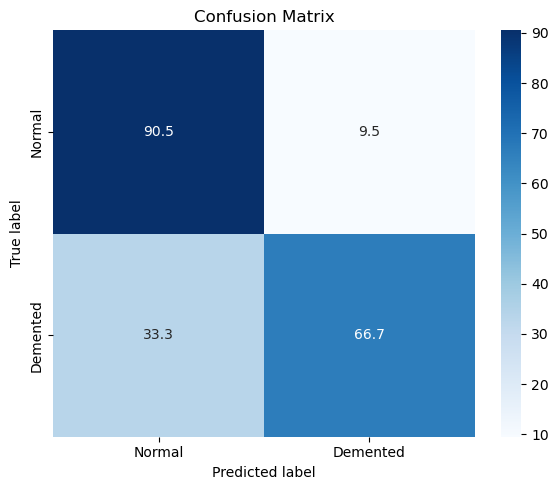

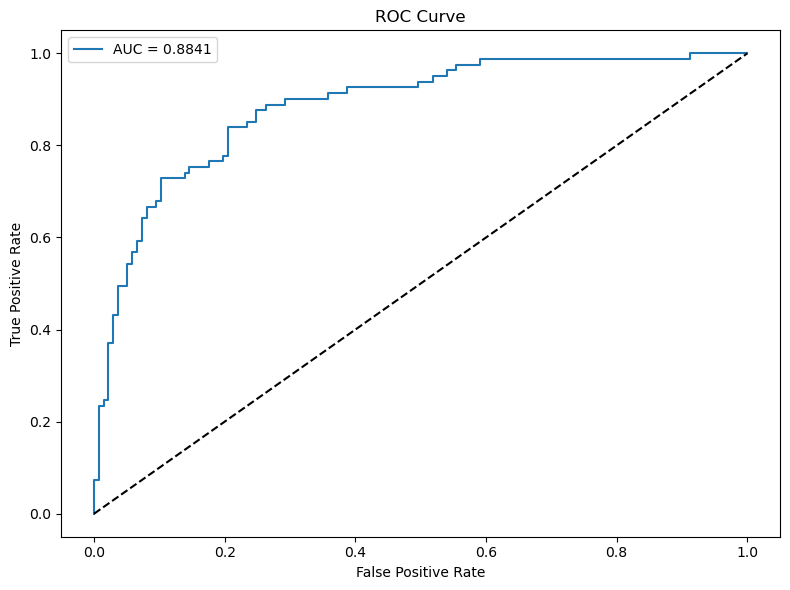

In [12]:
test_metrics = test_model(final_model, final_test_loader, DEVICE, plot=True, save=True)


## 12 · Young Subject Subgroup Analysis


Young test subset: Age < 75
Number of subjects: 151

Class distribution:
label
Normal      116
Demented     35
Name: count, dtype: int64

Class distribution (%):
label
Normal      76.821192
Demented    23.178808
Name: proportion, dtype: float64

Age mean : 65.7
Age std  : 6.8
Age range: 45.8 - 74.7

===== TEST METRICS =====
Accuracy           : 0.8477
Macro Precision    : 0.8081
Weighted Precision : 0.8392
Macro Recall       : 0.7313
Weighted Recall    : 0.8477
Macro F1-score     : 0.7578
Weighted F1-score  : 0.8369
ROC AUC            : 0.8650

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Normal     0.8661    0.9483    0.9053       116
    Demented     0.7500    0.5143    0.6102        35

    accuracy                         0.8477       151
   macro avg     0.8081    0.7313    0.7578       151
weighted avg     0.8392    0.8477    0.8369       151



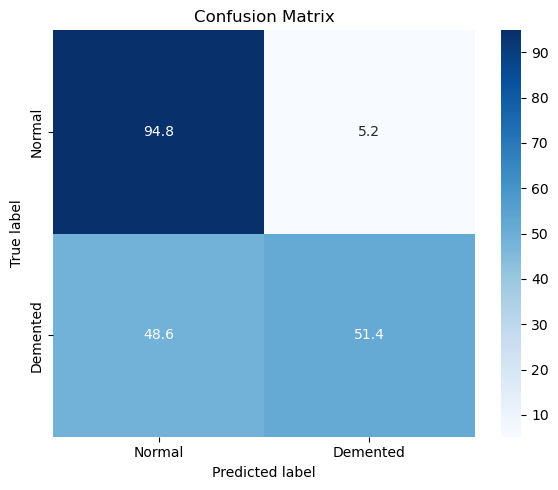

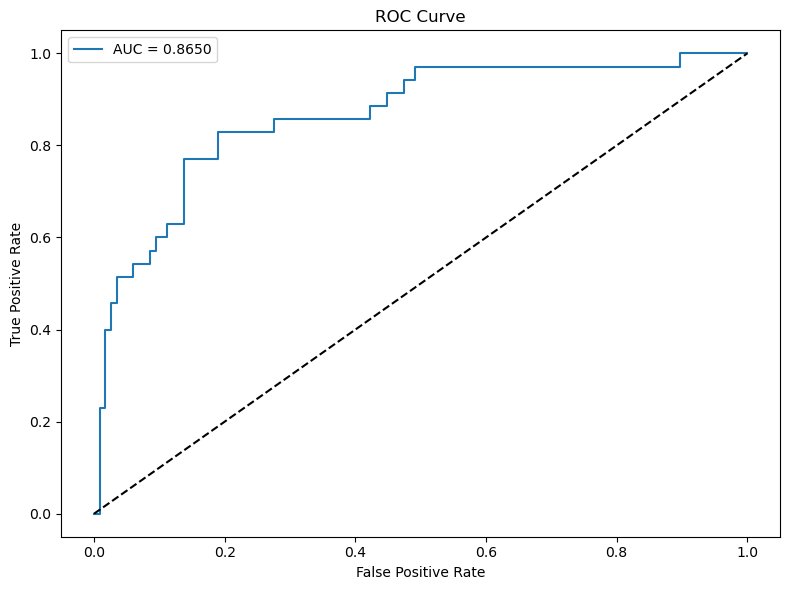


===== YOUNG TEST METRICS DICT =====
{'accuracy': 0.847682119205298, 'precision_macro': 0.8080708661417323, 'precision_weighted': 0.8392214632111383, 'recall_macro': 0.7312807881773399, 'recall_weighted': 0.847682119205298, 'f1_macro': 0.7577596428820534, 'f1_weighted': 0.8369305187753447, 'auc': 0.8650246305418718, 'confusion_matrix': array([[110,   6],
       [ 17,  18]])}


In [13]:
from torch.utils.data import DataLoader

# =========================================================
# Young Subject Subgroup Analysis
# =========================================================

AGE_THRESHOLD = 75

# Filter only young subjects from the original test set
young_test_df = test_df[test_df["Age"] < AGE_THRESHOLD].copy()

print("=" * 55)
print(f"Young test subset: Age < {AGE_THRESHOLD}")
print("=" * 55)

print(f"Number of subjects: {len(young_test_df)}")
print("\nClass distribution:")
print(young_test_df["label"].value_counts().rename({0: "Normal", 1: "Demented"}))

print("\nClass distribution (%):")
print((young_test_df["label"].value_counts(normalize=True) * 100).rename({0: "Normal", 1: "Demented"}))

print(f"\nAge mean : {young_test_df['Age'].mean():.1f}")
print(f"Age std  : {young_test_df['Age'].std():.1f}")
print(f"Age range: {young_test_df['Age'].min():.1f} - {young_test_df['Age'].max():.1f}")

# Create DataLoader for young test subjects
young_test_loader = DataLoader(
    OASIS3DDataset(young_test_df, augment=False),
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Evaluate model on young test subset
young_test_metrics = test_model(
    final_model,
    young_test_loader,
    DEVICE,
    plot=True,
    save=True
)

print("\n===== YOUNG TEST METRICS DICT =====")
print(young_test_metrics)

## 13 · 3D Grad-CAM

Grad-CAM for a 3D CNN produces a **3D heatmap** (same spatial resolution as the input volume after upsampling).

**Target layer:** the last `Conv3DBlock` in the encoder — the deepest feature maps before Global Average Pooling.  
Since the block contains two `Conv3d` layers, we hook the **second BN→ReLU output** (last spatial activations before MaxPool).

The 3D heatmap is visualized as three central orthogonal slices:
- **Axial** (top-down view)
- **Coronal** (front view)
- **Sagittal** (side view)


In [14]:
import torch.nn.functional as F


def gradcam_3d(model, input_tensor, device, target_class=None):

    model.eval()
    input_tensor = input_tensor.to(device)

    activations = []
    gradients   = []

    # ── Deshabilitar ReLU inplace temporalmente ────────────────────────────
    # inplace=True causa el error con los backward hooks
    def disable_inplace(m):
        if isinstance(m, nn.ReLU):
            m.inplace = False

    def enable_inplace(m):
        if isinstance(m, nn.ReLU):
            m.inplace = True

    model.apply(disable_inplace)

    # ── Target layer: salida del último Conv3DBlock completo ───────────────
    last_block = None
    for layer in model.encoder:
        if isinstance(layer, Conv3DBlock):
            last_block = layer

    if last_block is None:
        raise ValueError("No Conv3DBlock found in model.encoder")

    # Hook sobre el bloque entero — evita hookear dentro de operaciones inplace
    def forward_hook(module, input, output):
        activations.append(output.detach().clone())

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach().clone())

    fh = last_block.register_forward_hook(forward_hook)
    bh = last_block.register_full_backward_hook(backward_hook)

    # ── Forward pass ───────────────────────────────────────────────────────
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    if target_class is None:
        target_class = pred_class

    # ── Backward pass ──────────────────────────────────────────────────────
    model.zero_grad()
    output[0, target_class].backward()

    fh.remove()
    bh.remove()

    # ── Restaurar inplace ──────────────────────────────────────────────────
    model.apply(enable_inplace)

    # ── Compute Grad-CAM ───────────────────────────────────────────────────
    grads = gradients[0]    # (1, C, d, h, w)
    acts  = activations[0]  # (1, C, d, h, w)

    weights = grads.mean(dim=(2, 3, 4), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = F.relu(cam)

    D, H, W = input_tensor.shape[2], input_tensor.shape[3], input_tensor.shape[4]
    cam = F.interpolate(cam, size=(D, H, W), mode='trilinear', align_corners=False)

    cam = cam.squeeze().cpu().numpy()
    cam -= cam.min()
    if cam.max() > 0:
        cam /= cam.max()

    return cam, pred_class

In [22]:
def plot_gradcam_3d(volume, heatmap, pred_class, title=None, label_names=["CN", "AD"], alpha=0.75):
    """
    Visualize a 3D Grad-CAM heatmap as three central orthogonal slices.

    Each row shows: original MRI slice | Grad-CAM heatmap | overlay.
    """
    if title is None:
        title = f"Grad-CAM — Predicted: {label_names[pred_class]}"

    # Remove batch/channel dims:
    vol = volume.squeeze().cpu().numpy()   # (D, H, W)

    D, H, W = vol.shape
    slices = {
        "Axial (z)"    : (vol[D//2, :, :],    heatmap[D//2, :, :]),
        "Coronal (y)"  : (vol[:, H//2, :],    heatmap[:, H//2, :]),
        "Sagittal (x)" : (vol[:, :, W//2],    heatmap[:, :, W//2]),
    }

    fig, axes = plt.subplots(3, 3, figsize=(14, 12))
    fig.suptitle(title, fontsize=18, fontweight="bold", y=1.01)

    for row, (plane_name, (mri_slice, cam_slice)) in enumerate(slices.items()):
        p1, p99 = np.percentile(mri_slice, [1, 99])

        # Panel 1: MRI slice
        axes[row, 0].imshow(mri_slice, cmap="gray", vmin=p1, vmax=p99, aspect="auto")
        axes[row, 0].set_title(f"{plane_name} — MRI", fontsize=12)
        axes[row, 0].axis("off")

        # Panel 2: Grad-CAM heatmap
        axes[row, 1].imshow(cam_slice, cmap="magma", aspect="auto", vmin=0, vmax=1)
        axes[row, 1].set_title(f"{plane_name} — Grad-CAM", fontsize=12)
        axes[row, 1].axis("off")

        # Panel 3: Overlay
        axes[row, 2].imshow(mri_slice, cmap="gray", vmin=p1, vmax=p99, aspect="auto")
        axes[row, 2].imshow(cam_slice, cmap="magma", alpha=alpha, aspect="auto", vmin=0, vmax=1)
        axes[row, 2].set_title(f"{plane_name} — Overlay", fontsize=12)
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()


In [16]:
def plot_misclassified_3d(misclassified_list, true_class_name, pred_class_name, max_samples=3):
    """Show Grad-CAM for the first N misclassified subjects."""
    n = len(misclassified_list)
    if n == 0:
        print(f"No misclassified {true_class_name} samples found.")
        return
    print(f"\n{'─'*60}")
    print(f"  {true_class_name} → {pred_class_name}: {n} misclassified subject(s)")
    print(f"{'─'*60}")
    for idx, entry in enumerate(misclassified_list[:max_samples]):
        print(f"\nSample {idx+1}/{min(n, max_samples)} | True: {true_class_name} → Predicted: {pred_class_name}")
        plot_gradcam_3d(entry["input"], entry["heatmap"], entry["pred"])


In [17]:
# ── Compute Grad-CAM for all test subjects ────────────────────────────────

cn_heatmaps      = []   # True CN — correct predictions
ad_heatmaps      = []   # True AD — correct predictions
cn_volumes       = []   # CN input volumes (for average MRI)
ad_volumes       = []   # AD input volumes
cn_misclassified = []   # True CN predicted as AD
ad_misclassified = []   # True AD predicted as CN

final_model.eval()
test_dataset_gradcam = OASIS3DDataset(test_df, augment=False)

print(f"Computing Grad-CAM for {len(test_dataset_gradcam)} test subjects...")

for i in tqdm(range(len(test_dataset_gradcam)), desc="Grad-CAM"):
    volume, label = test_dataset_gradcam[i]
    input_single  = volume.unsqueeze(0)   # (1, 1, D, H, W)
    label         = label.item()

    heatmap, pred_class = gradcam_3d(final_model, input_single, DEVICE)

    if pred_class == label:
        if label == 0:
            cn_heatmaps.append(heatmap)
            cn_volumes.append(volume.squeeze().numpy())
        else:
            ad_heatmaps.append(heatmap)
            ad_volumes.append(volume.squeeze().numpy())
    else:
        entry = {"input": input_single, "heatmap": heatmap, "true": label, "pred": pred_class}
        if label == 0:
            cn_misclassified.append(entry)
        else:
            ad_misclassified.append(entry)

print(f"\nCorrect CN: {len(cn_heatmaps)}  |  Correct AD: {len(ad_heatmaps)}")
print(f"CN→AD misclassified: {len(cn_misclassified)}  |  AD→CN misclassified: {len(ad_misclassified)}")

# Compute mean heatmap and mean volume per class:
mean_cn_heatmap = np.mean(cn_heatmaps, axis=0)
mean_ad_heatmap = np.mean(ad_heatmaps, axis=0)
mean_cn_volume  = torch.tensor(np.mean(cn_volumes, axis=0)).unsqueeze(0).unsqueeze(0)
mean_ad_volume  = torch.tensor(np.mean(ad_volumes, axis=0)).unsqueeze(0).unsqueeze(0)


Computing Grad-CAM for 218 test subjects...


Grad-CAM:   0%|          | 0/218 [00:00<?, ?it/s]


Correct CN: 124  |  Correct AD: 54
CN→AD misclassified: 13  |  AD→CN misclassified: 27


── Average CN (correctly classified) ──


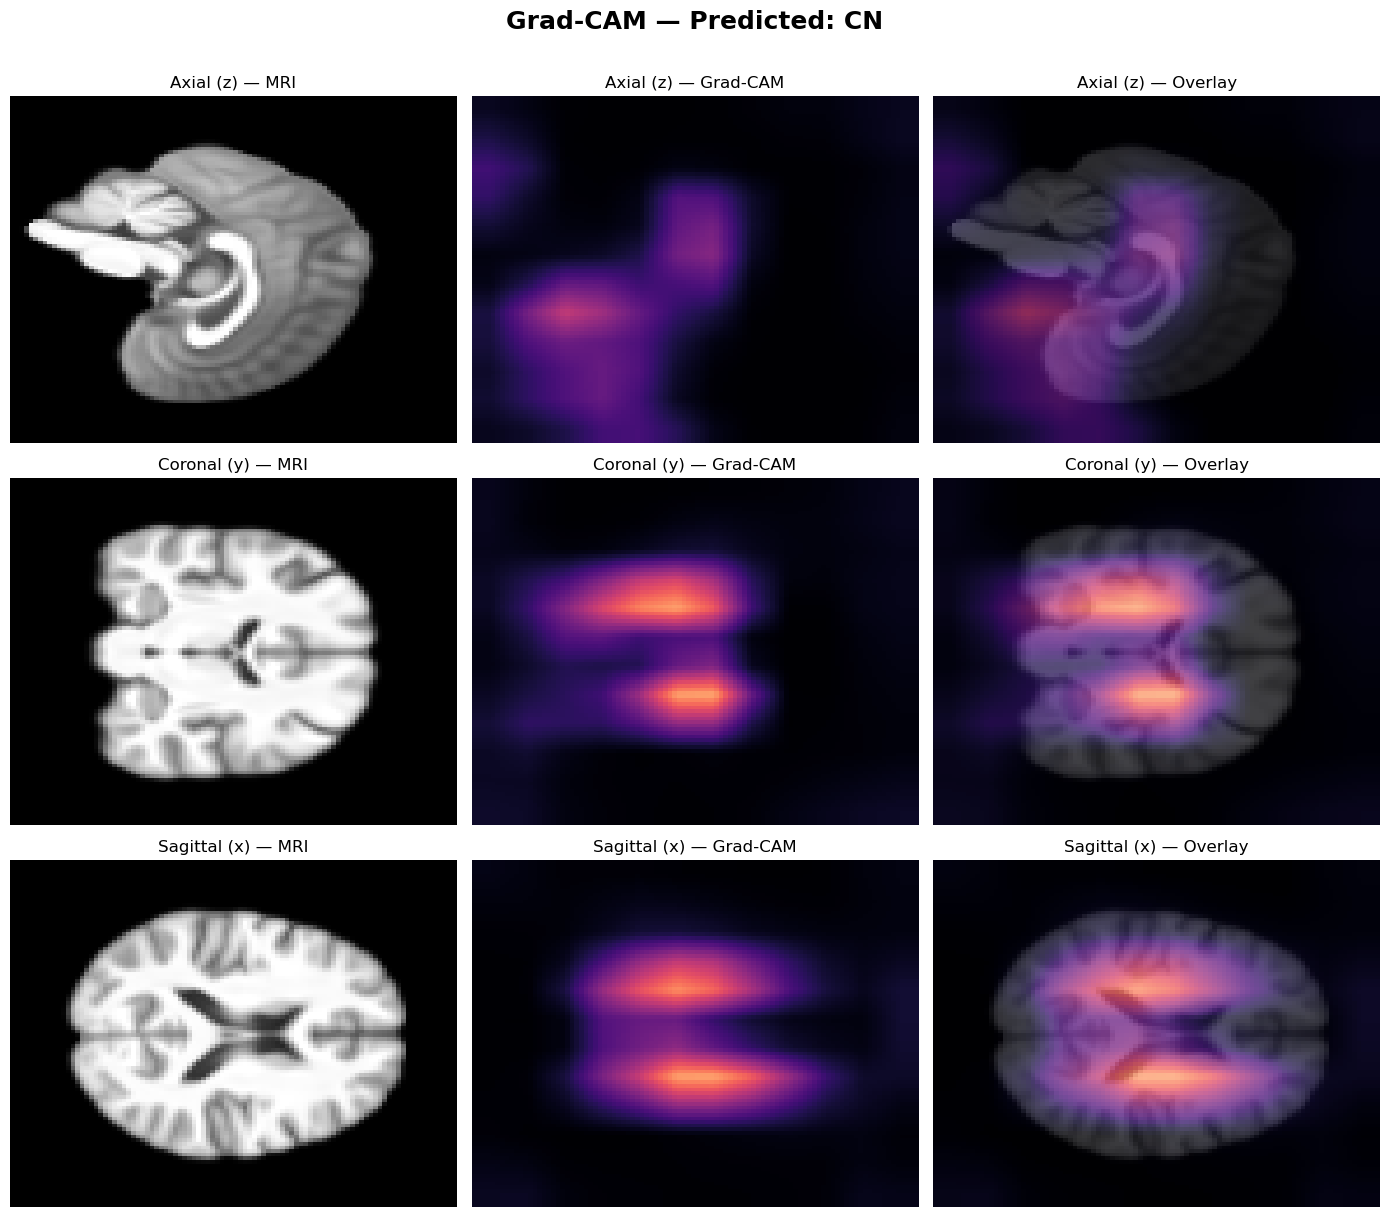

── Average AD (correctly classified) ──


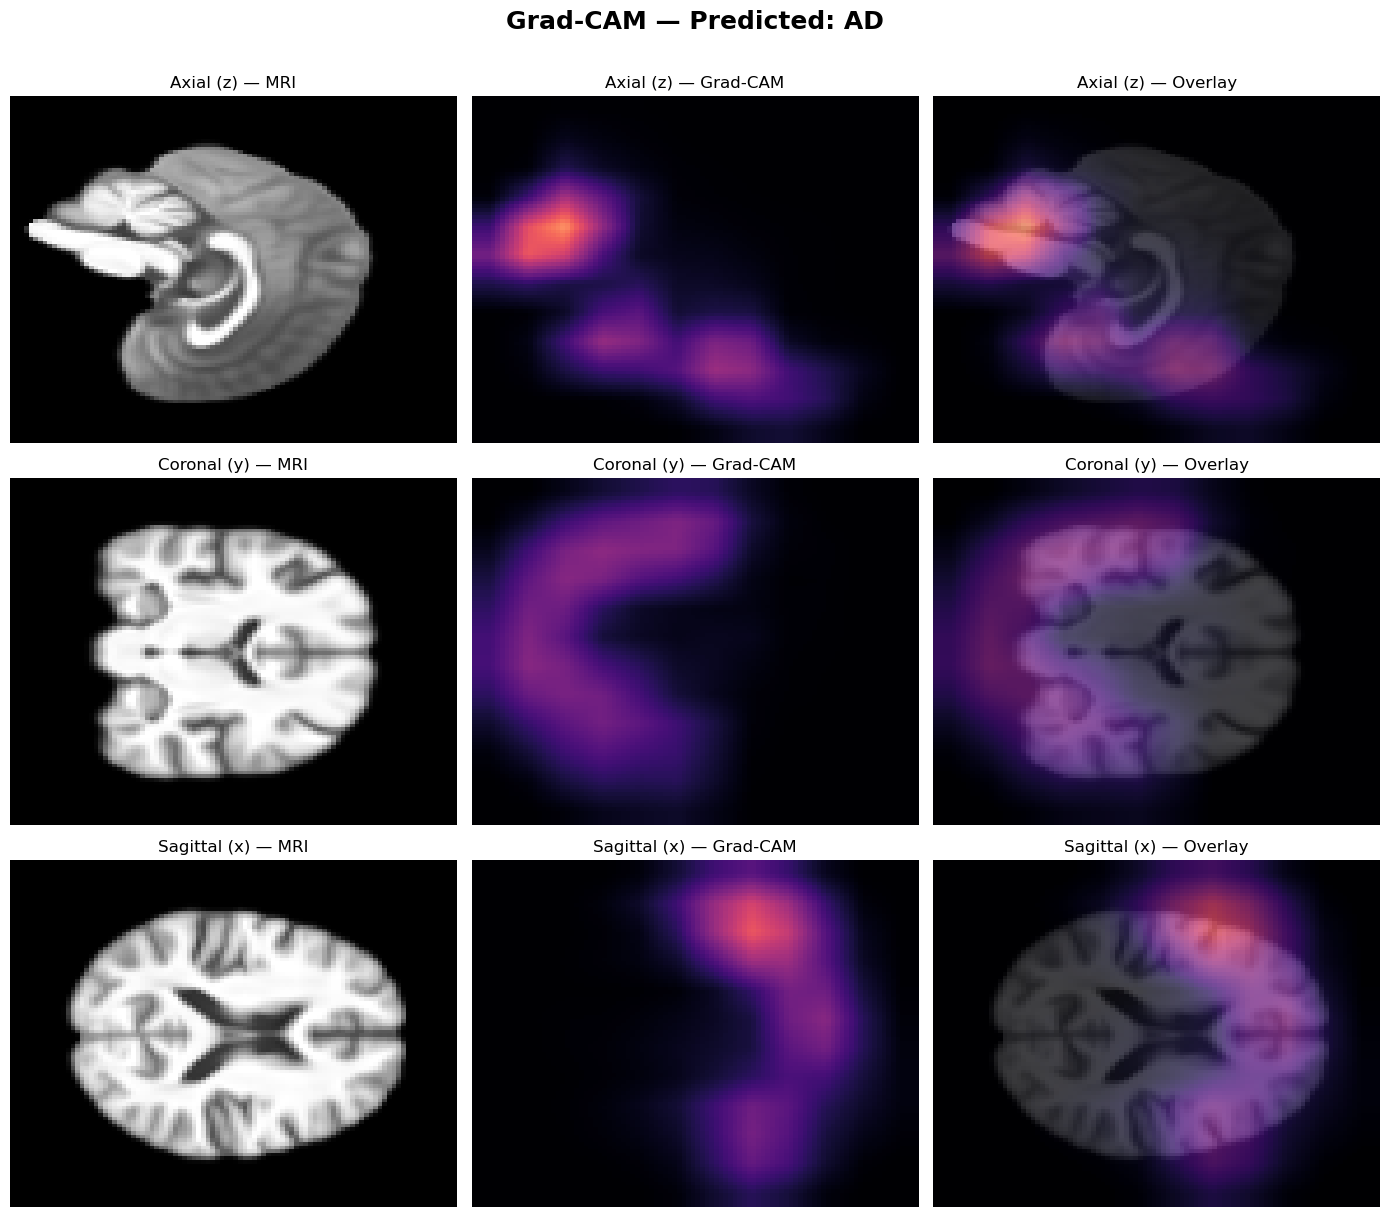

In [23]:
# ── Average Grad-CAM per class ─────────────────────────────────────────────

print("── Average CN (correctly classified) ──")
plot_gradcam_3d(mean_cn_volume, mean_cn_heatmap, pred_class=0)

print("── Average AD (correctly classified) ──")
plot_gradcam_3d(mean_ad_volume, mean_ad_heatmap, pred_class=1)



────────────────────────────────────────────────────────────
  CN → AD: 13 misclassified subject(s)
────────────────────────────────────────────────────────────

Sample 1/3 | True: CN → Predicted: AD


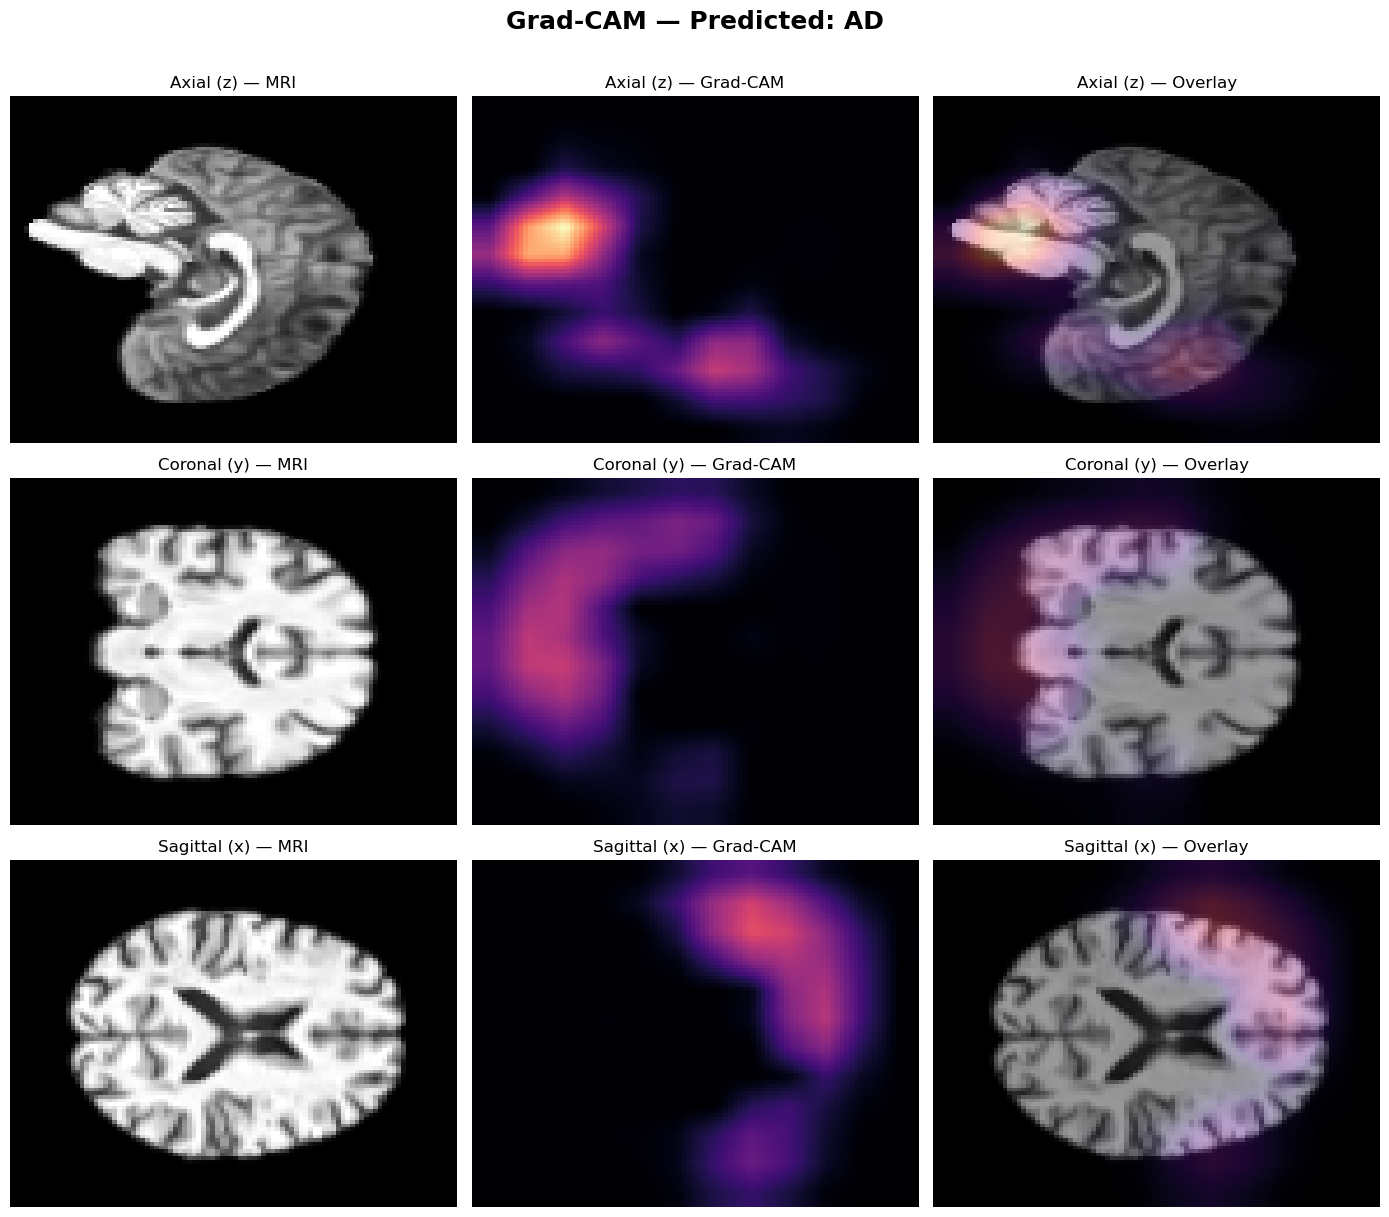


Sample 2/3 | True: CN → Predicted: AD


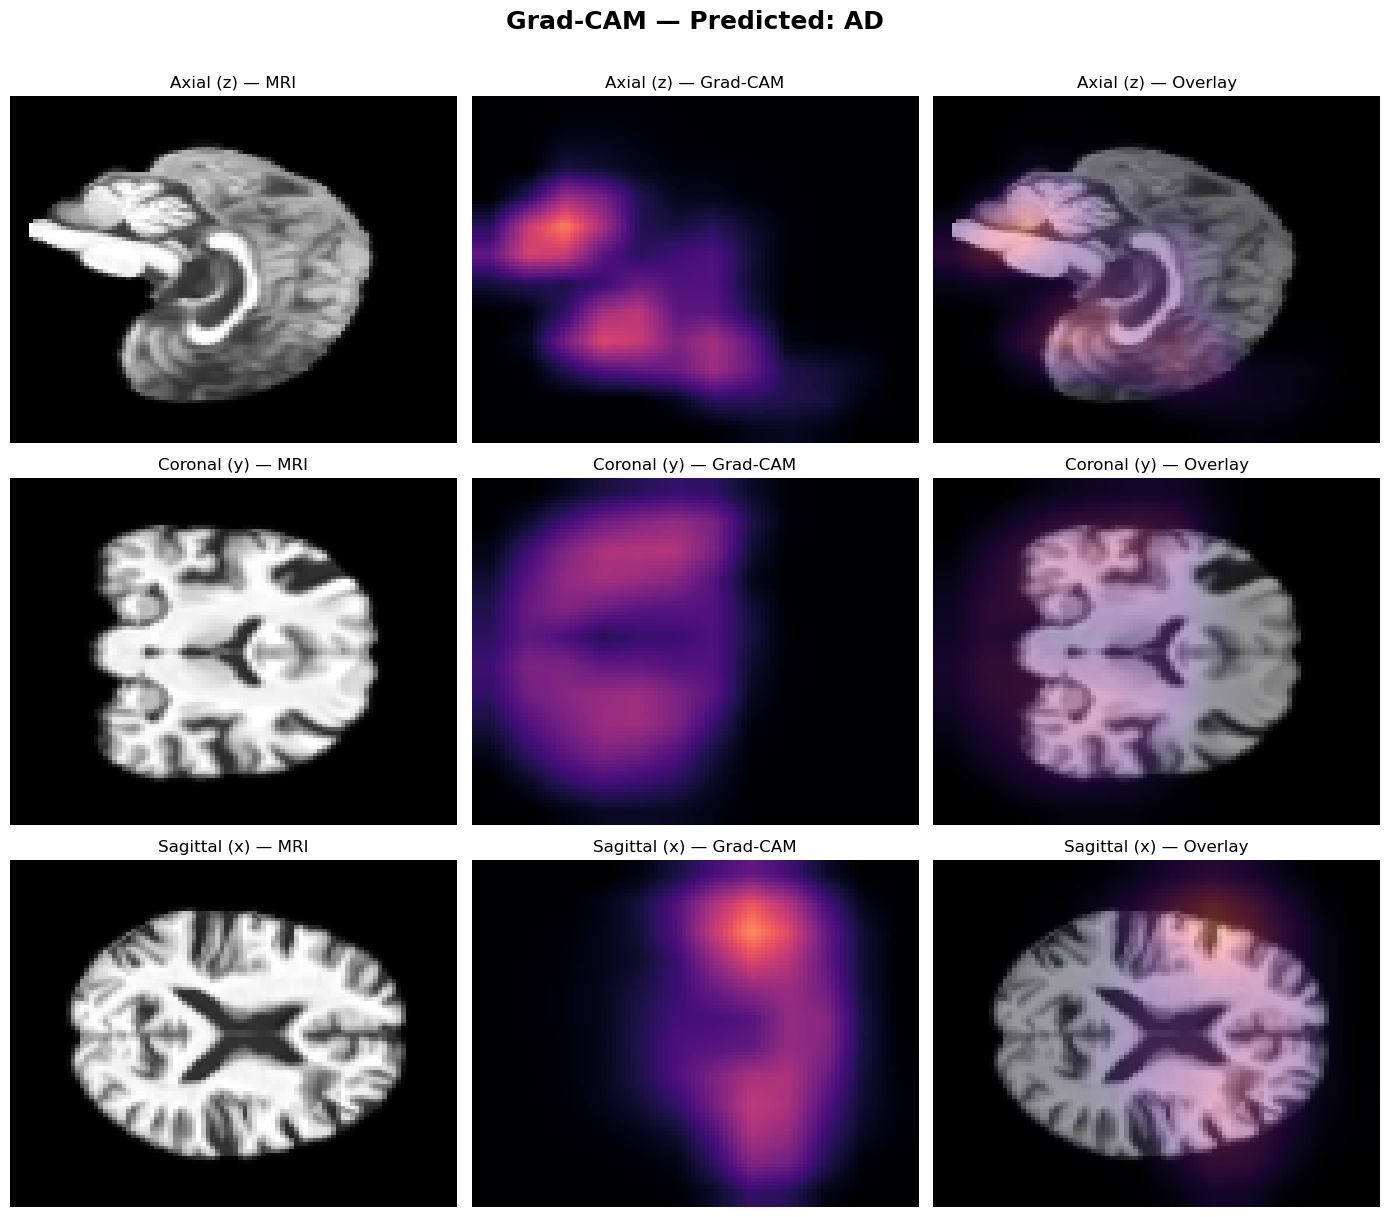


Sample 3/3 | True: CN → Predicted: AD


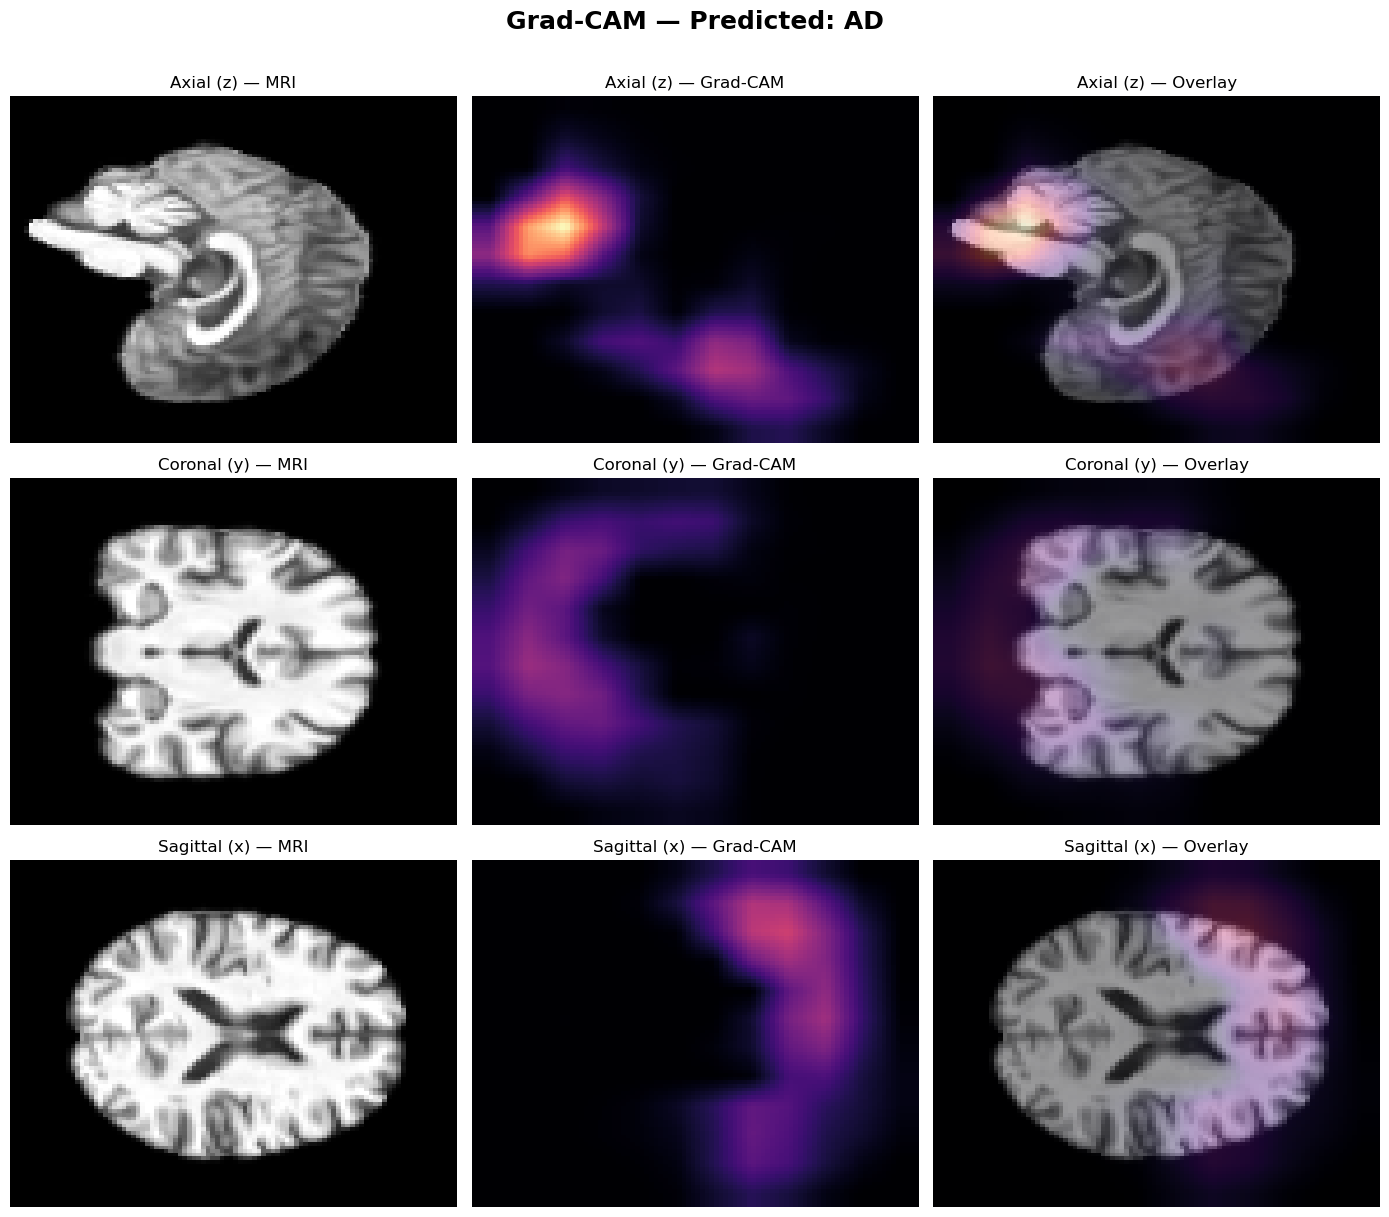


────────────────────────────────────────────────────────────
  AD → CN: 27 misclassified subject(s)
────────────────────────────────────────────────────────────

Sample 1/3 | True: AD → Predicted: CN


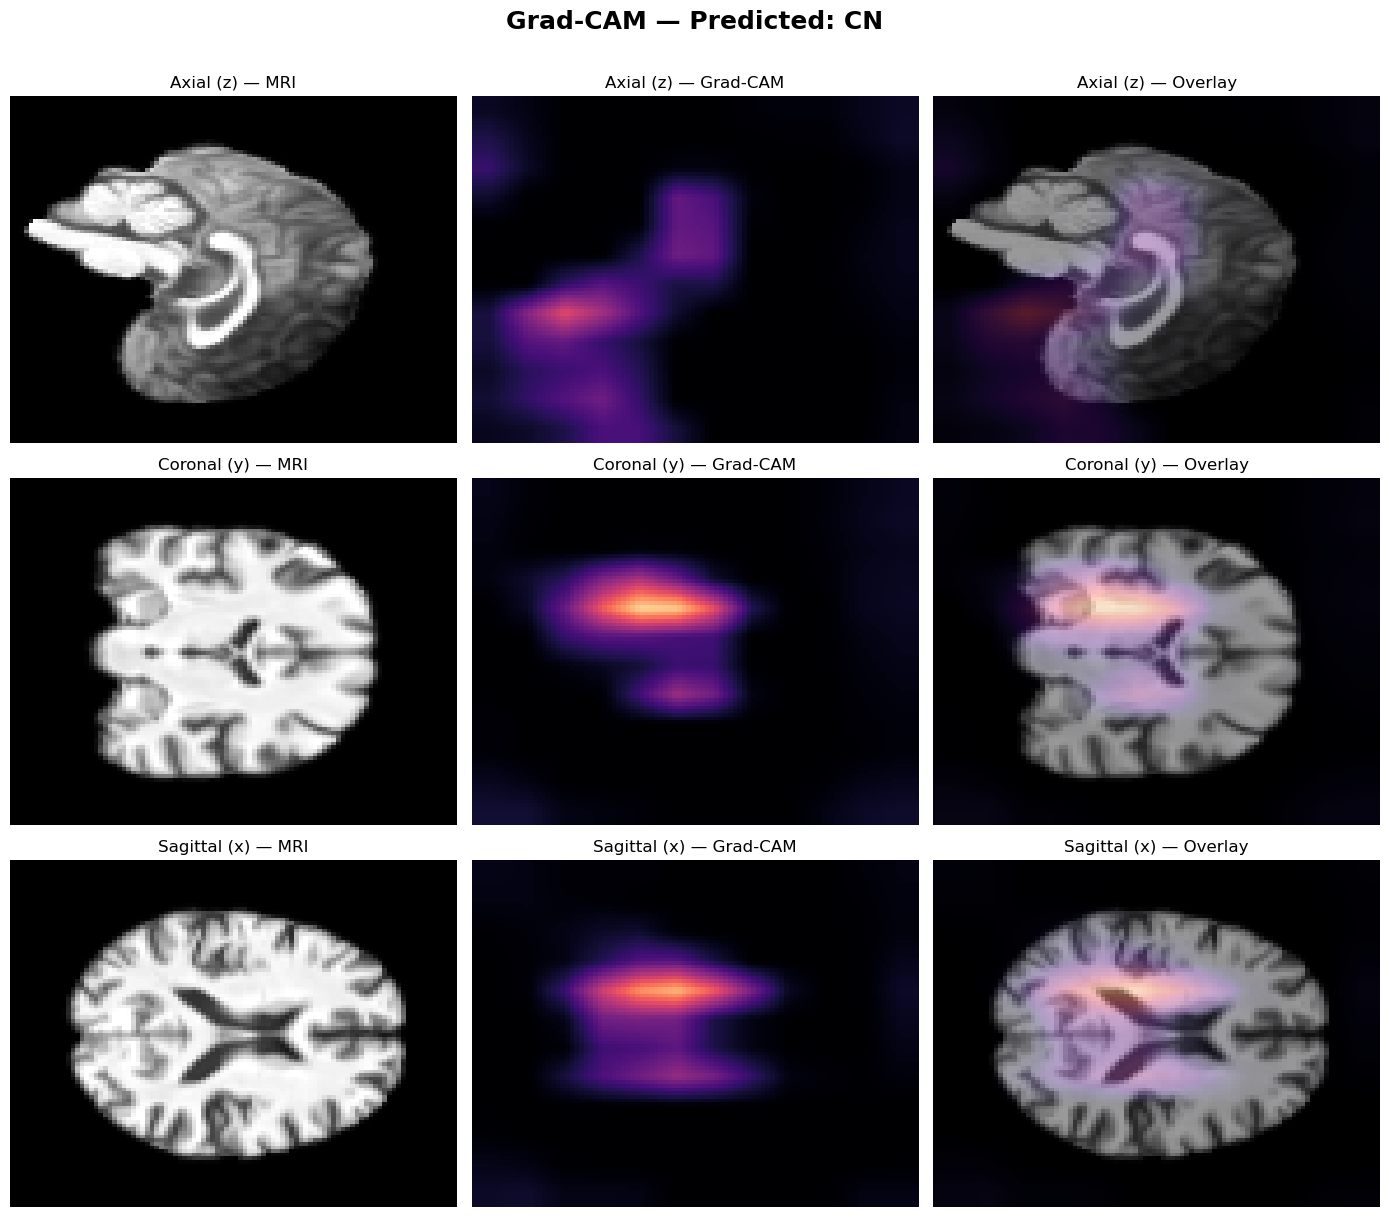


Sample 2/3 | True: AD → Predicted: CN


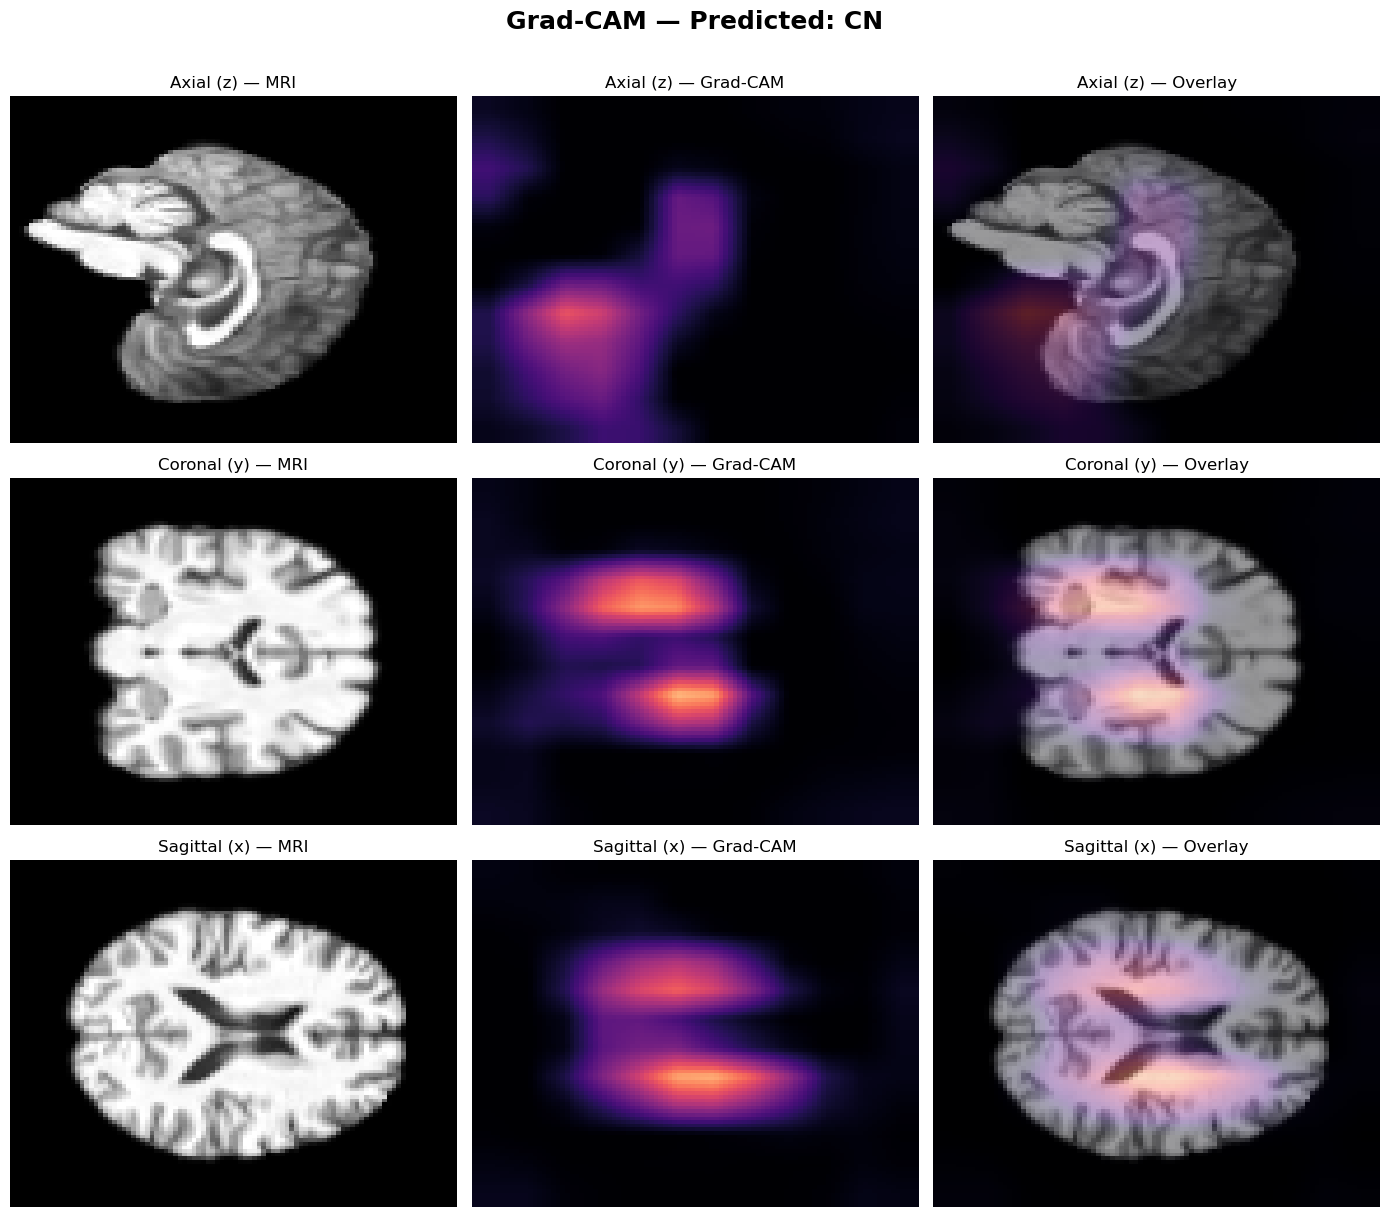


Sample 3/3 | True: AD → Predicted: CN


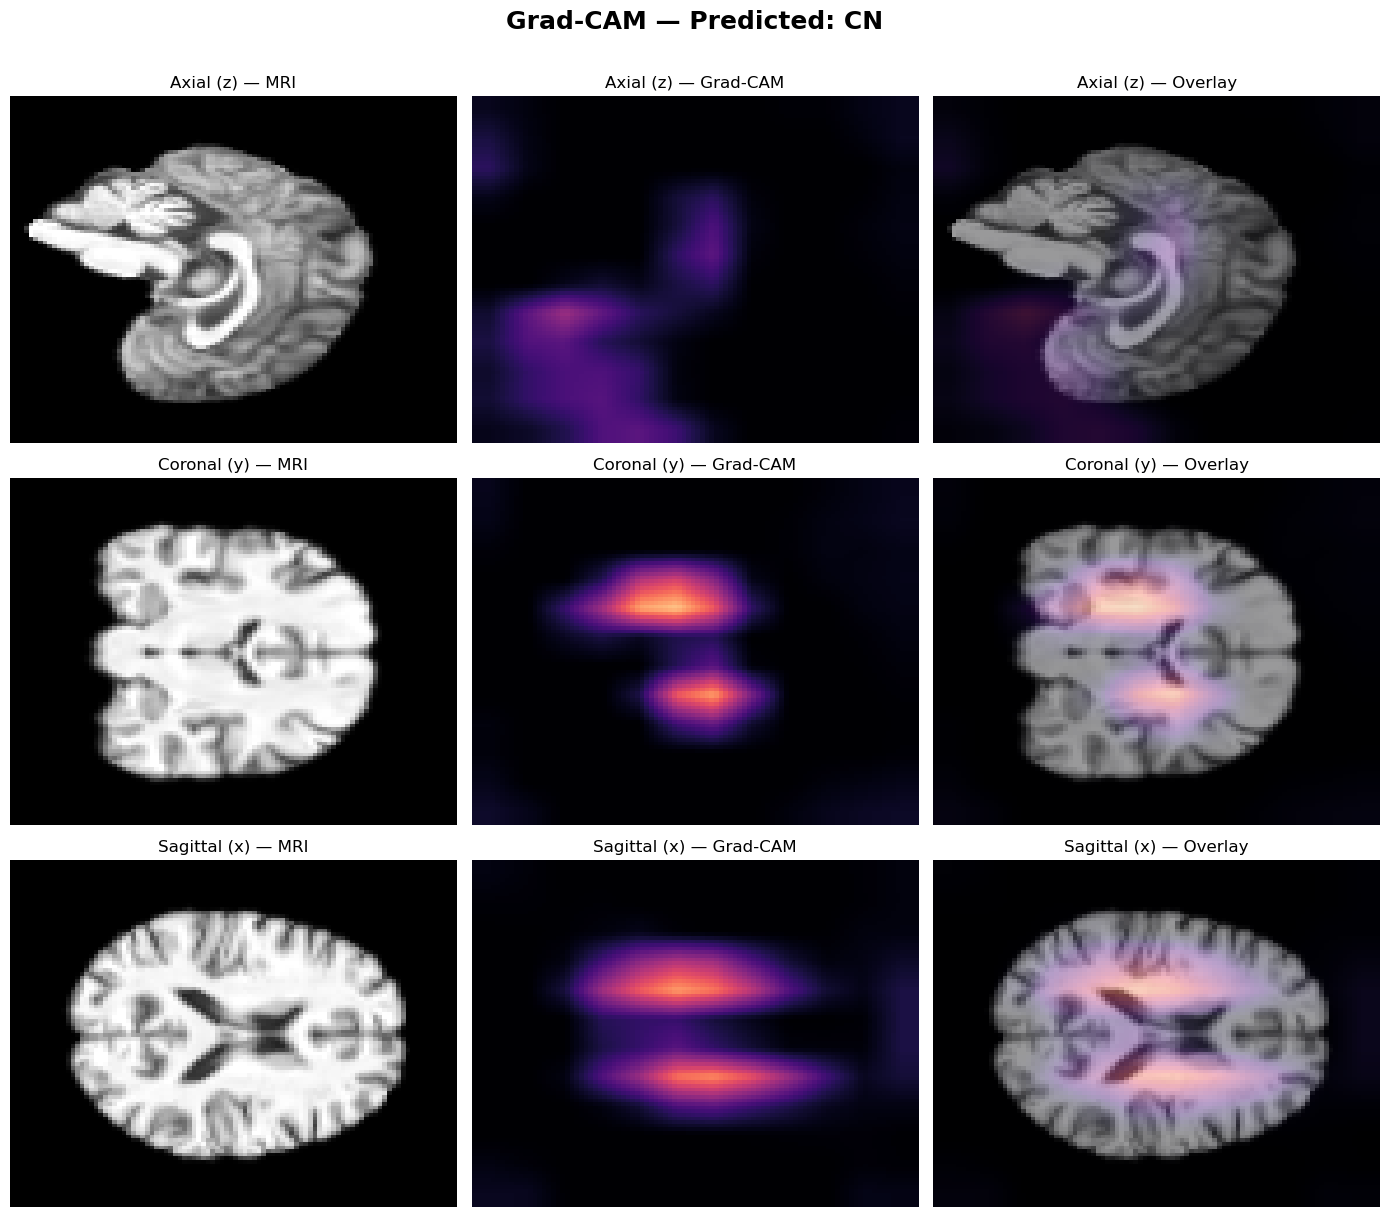

In [19]:
# ── Misclassified subjects ──────────────────────────────────────────────────

plot_misclassified_3d(cn_misclassified, "CN", "AD", max_samples=3)
plot_misclassified_3d(ad_misclassified, "AD", "CN", max_samples=3)
